In [1]:
!pip install split-folders tensorflow kagglehub

# Rice Dataset CNN Model

In [27]:
# Download dataset
path = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Dataset Path: /kaggle/input/rice-image-dataset


In [28]:
os.listdir(path)

['Rice_Image_Dataset']

In [29]:
import os
import splitfolders

# Go inside rice folder
input_folder = os.path.join(path, "Rice_Image_Dataset")

output_folder = "rice_split"

# Corrected: Allocate 10% of data to the test set
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.8, 0.1, 0.1) # 80% train, 10% val, 10% test
)

print("Data split successfully!")

Copying files: 75000 files [05:18, 235.16 files/s]

Data split successfully!


In [30]:
!ls rice_split/test

Arborio  Basmati  Ipsala  Jasmine  Karacadag


In [31]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse' # Changed from 'binary' to 'sparse'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse' # Changed from 'binary' to 'sparse'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse' # Changed from 'binary' to 'sparse'
)

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
Found 7500 images belonging to 5 classes.


In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the input shape (based on your image_dataset_from_directory setup)
INPUT_SHAPE = (150, 150, 3) # Height, Width, Color Channels (RGB)
NUM_CLASSES = 5          # You have 5 classes

#### MaxPooling2D reduces the spatial size of feature maps by taking the maximum value from each small region, keeping the strongest features while lowering computation.

#### In Conv2D(32, (3,3)), 32 means the number of filters (kernels) the layer will learn.

That means the layer will produce 32 different feature maps, each detecting a different pattern (like edges, textures, shapes, etc.).

In [33]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(264, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax') # Changed output layer for 5 classes
])

# Display the model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 264)    │       304,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 264)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12936)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     6,623,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,023,949 (26.79 MB)

 Trainable params: 7,023,949 (26.79 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [35]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import os

# 1. Define the directory to save the checkpoints
checkpoint_dir = './training_checkpoints_cnn'
os.makedirs(checkpoint_dir, exist_ok=True) # Create the folder if it doesn't exist

# 2. Define the filepath for the model files
# The format includes epoch number and the validation loss/accuracy
checkpoint_filepath = os.path.join(
    checkpoint_dir,
    'rice_cnn_model_{epoch:02d}-{val_accuracy:.4f}.keras'
)

# 3. Create the ModelCheckpoint callback
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,       # Set to True if you only want to save weights
    monitor='val_accuracy',        # Metric to monitor (e.g., 'val_loss' or 'val_accuracy')
    mode='max',                    # 'max' means we look for the highest val_accuracy
    save_best_only=True,           # Only save a model if 'val_accuracy' improves
    verbose=1                      # Log when a new best model is saved
)

In [36]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 383s 202ms/step - accuracy: 0.9095 - loss: 0.2334 - val_accuracy: 0.9689 - val_loss: 0.0922
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 376s 200ms/step - accuracy: 0.9772 - loss: 0.0708 - val_accuracy: 0.9335 - val_loss: 0.2395
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 373s 199ms/step - accuracy: 0.9811 - loss: 0.0574 - val_accuracy: 0.8422 - val_loss: 0.8938
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 381s 203ms/step - accuracy: 0.9828 - loss: 0.0537 - val_accuracy: 0.8629 - val_loss: 0.7904
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 382s 204ms/step - accuracy: 0.9848 - loss: 0.0460 - val_accuracy: 0.8433 - val_loss: 1.1701
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 377s 201ms/step - accuracy: 0.9863 - loss: 0.0440 - val_accuracy: 0.9727 - val_loss: 0.1078
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 393s 210ms/step - accuracy: 0.9867 - loss: 0.0410 - val_accuracy: 0.9161 - val_loss: 0.4145
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 385s 205ms/step - ac

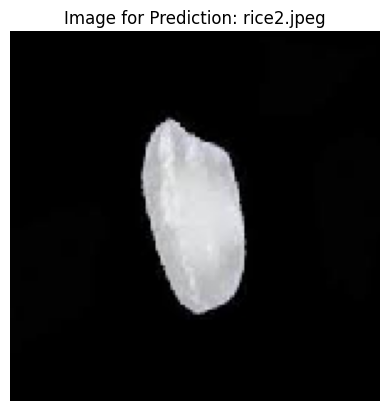

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction probabilities:
Arborio: 1.000
Basmati: 0.000
Ipsala: 0.000
Jasmine: 0.000
Karacadag: 0.000


In [50]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming rice.jpg is in the /content/ directory or sample_data/ directory.
# If you intend to use an image from the 'rice_split' dataset, you'll need to locate one.
image_path = "/content/rice2.jpeg" # Corrected path to an existing image in Colab environment

# Corrected target_size to match IMG_SIZE (150, 150) from model definition
img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img) / 255.0 # Scaled once
img_array = tf.expand_dims(img_array, 0)

# 6️⃣ Show image preview
plt.imshow(img)
plt.axis('off')
plt.title(f"Image for Prediction: {os.path.basename(image_path)}")
plt.show()

# Check if train_generator is defined to get class names
if 'train_generator' not in locals():
    print("Error: 'train_generator' is not defined. Please run the data generator setup cells.")
    class_names = []
else:
    class_names = list(train_generator.class_indices.keys())

if not class_names:
    print("Cannot perform prediction: class names are not available.")
else:
    preds = model.predict([img_array])[0]

    print("Prediction probabilities:")
    if len(preds) == len(class_names):
        for i, name in enumerate(class_names):
            print(f"{name}: {preds[i]:.3f}")
    else:
        print("Model output shape does not match the number of classes. Check your model's last layer.")
        print(f"Predicted array length: {len(preds)}, Expected classes: {len(class_names)}")

In [51]:
model_save_path = 'rice_cnn_model.keras'
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to rice_cnn_model.keras
